# Alpine River Change (Long-Term, Single Download)

This version avoids per-year API calls (which caused 429 rate limits).

Workflow:
1. Load one long time cube for the AOI
2. Compute NDWI
3. Aggregate to yearly NDWI composites
4. Build yearly water masks and trend plots

In [1]:
from __future__ import annotations

from datetime import datetime
from pathlib import Path
from time import perf_counter
import hashlib
import json

import matplotlib
%matplotlib widget
import matplotlib.pyplot as plt
import numpy as np
import openeo
import xarray as xr


matplotlib.rcParams["text.usetex"] = False
matplotlib.rcParams["font.family"] = "sans-serif"
matplotlib.rcParams["font.sans-serif"] = ["DejaVu Sans", "Liberation Sans", "Arial"]
matplotlib.rcParams["mathtext.fontset"] = "dejavusans"

In [2]:
# Parameters (edit here)
AOI = {
    "west": 11.293602,
    "east": 11.382866,
    "south": 46.460163,
    "north": 46.514768,
    "crs": "EPSG:4326",
}

COLLECTION_ID = "LANDSAT_BIMONTHLY_MOSAIC"
BLUE_BAND = "B02"
GREEN_BAND = "B03"
RED_BAND = "B04"
NIR_BAND = "B05"

REQUESTED_START_YEAR = 1975
REQUESTED_END_YEAR = datetime.now().year - 1

# LANDSAT_BIMONTHLY_MOSAIC does not support eo:cloud_cover queryable -> keep False
USE_CLOUD_FILTER = False
MAX_CLOUD_COVER = 40.0

NDWI_THRESHOLD = 0.05
FORCE_DOWNLOAD = False

def find_project_root(start: Path) -> Path:
    p = start.resolve()
    for candidate in [p] + list(p.parents):
        if (candidate / "data").exists() and (candidate / "src").exists():
            return candidate
    return p

ROOT = find_project_root(Path.cwd())
DATA_DIR = ROOT / "data" / "river_change_50y"
FIG_DIR = ROOT / "figures"
DATA_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"ROOT: {ROOT}")
print(f"Collection: {COLLECTION_ID} (RGB={RED_BAND}/{GREEN_BAND}/{BLUE_BAND}, NIR={NIR_BAND})")


ROOT: /home/vsilv/.nextcloud/src/cassini/11th_cassini_hackathon/python_analysis
Collection: LANDSAT_BIMONTHLY_MOSAIC (RGB=B04/B03/B02, NIR=B05)


In [3]:
def parse_collection_year_bounds(md: dict) -> tuple[int | None, int | None]:
    intervals = md.get("extent", {}).get("temporal", {}).get("interval", [])
    starts = []
    ends = []
    for s, e in intervals:
        if s:
            starts.append(int(str(s)[:4]))
        if e:
            ends.append(int(str(e)[:4]))
    return (min(starts) if starts else None, max(ends) if ends else None)

def long_cache_path(collection_id: str, start_year: int, end_year: int, aoi: dict, cloud: float, use_cloud_filter: bool, bands: list[str]) -> Path:
    payload = {
        "collection": collection_id,
        "start": start_year,
        "end": end_year,
        "aoi": aoi,
        "cloud": cloud,
        "use_cloud_filter": use_cloud_filter,
        "bands": sorted(bands),
    }
    key = hashlib.md5(json.dumps(payload, sort_keys=True).encode("utf-8")).hexdigest()[:12]
    return DATA_DIR / f"{collection_id}_{start_year}_{end_year}_{key}.nc"

def download_long_cube_if_needed(
    conn,
    collection_id: str,
    aoi: dict,
    bands: list[str],
    start_year: int,
    end_year: int,
    use_cloud_filter: bool,
    max_cloud_cover: float,
    force_download: bool,
) -> Path:
    nc_path = long_cache_path(collection_id, start_year, end_year, aoi, max_cloud_cover, use_cloud_filter, bands)
    if nc_path.exists() and not force_download:
        try:
            ds_cached = xr.open_dataset(nc_path)
            missing_cached = [b for b in bands if b not in ds_cached.variables]
            ds_cached.close()
            if not missing_cached:
                print(f"Using cache: {nc_path}")
                return nc_path
            print(f"Cache missing bands {missing_cached}, re-downloading: {nc_path.name}")
        except Exception as exc:
            print(f"Cache read failed ({exc}), re-downloading: {nc_path.name}")

    kwargs = dict(
        spatial_extent=aoi,
        temporal_extent=[f"{start_year}-01-01", f"{end_year}-12-31"],
        bands=bands,
    )
    if use_cloud_filter:
        kwargs["max_cloud_cover"] = max_cloud_cover

    cube = conn.load_collection(collection_id, **kwargs)
    print(f"Downloading long cube to: {nc_path}")
    cube.download(str(nc_path))
    return nc_path

def compute_yearly_products(nc_path: Path, blue_band: str, green_band: str, red_band: str, nir_band: str):
    ds = xr.open_dataset(nc_path)
    expected = [blue_band, green_band, red_band, nir_band]
    missing = [b for b in expected if b not in ds.variables]
    if missing:
        raise RuntimeError(f"Missing expected bands in {nc_path.name}: {missing}")

    if "t" not in ds[green_band].dims:
        raise RuntimeError("No temporal dimension found in cube; cannot build yearly series.")

    g = ds[green_band].astype("float32")
    n = ds[nir_band].astype("float32")
    ndwi = (g - n) / (g + n)
    yearly_ndwi = ndwi.groupby("t.year").median(dim="t", skipna=True)

    yearly_rgb = ds[[red_band, green_band, blue_band]].astype("float32").groupby("t.year").median(dim="t", skipna=True)
    return yearly_ndwi, yearly_rgb

def build_mask(ndwi_arr: np.ndarray, threshold: float) -> np.ndarray:
    mask = np.zeros_like(ndwi_arr, dtype=np.uint8)
    finite = np.isfinite(ndwi_arr)
    mask[finite & (ndwi_arr > threshold)] = 1
    return mask


In [4]:
# Run
t0 = perf_counter()

conn = openeo.connect("openeo.dataspace.copernicus.eu").authenticate_oidc()
ids = set(conn.list_collection_ids())
if COLLECTION_ID not in ids:
    raise ValueError(f"Collection {COLLECTION_ID} not available.")

md = conn.describe_collection(COLLECTION_ID)
start_cov, end_cov = parse_collection_year_bounds(md)
effective_start = max(REQUESTED_START_YEAR, start_cov) if start_cov else REQUESTED_START_YEAR
effective_end = min(REQUESTED_END_YEAR, end_cov) if end_cov else REQUESTED_END_YEAR

if effective_start > effective_end:
    raise RuntimeError("Requested years are outside collection temporal coverage.")

print(f"Collection temporal coverage: {start_cov}..{end_cov}")
print(f"Effective years: {effective_start}..{effective_end}")
print(f"Cloud filter used: {USE_CLOUD_FILTER}")

nc_path = download_long_cube_if_needed(
    conn=conn,
    collection_id=COLLECTION_ID,
    aoi=AOI,
    bands=[BLUE_BAND, GREEN_BAND, RED_BAND, NIR_BAND],
    start_year=effective_start,
    end_year=effective_end,
    use_cloud_filter=USE_CLOUD_FILTER,
    max_cloud_cover=MAX_CLOUD_COVER,
    force_download=FORCE_DOWNLOAD,
)

yearly_ndwi, yearly_rgb = compute_yearly_products(nc_path, BLUE_BAND, GREEN_BAND, RED_BAND, NIR_BAND)

years_ok = yearly_ndwi["year"].values.astype(int)
water_frac = []
maps = {}

for y in years_ok:
    arr = yearly_ndwi.sel(year=y).values
    mask = build_mask(arr, NDWI_THRESHOLD)
    finite = int(np.isfinite(arr).sum())
    water = int(mask.sum())
    frac = water / finite if finite else np.nan
    water_frac.append(frac)
    maps[int(y)] = mask

water_frac = np.array(water_frac, dtype=float)
lons = yearly_ndwi["x"].values.astype(float)
lats = yearly_ndwi["y"].values.astype(float)

print(f"Processed years: {len(years_ok)}")


Authenticated using refresh token.
Collection temporal coverage: 1997..2024
Effective years: 1997..2024
Cloud filter used: False
Using cache: /home/vsilv/.nextcloud/src/cassini/11th_cassini_hackathon/python_analysis/data/river_change_50y/LANDSAT_BIMONTHLY_MOSAIC_1997_2024_3fd03e23509d.nc
Processed years: 28


## Pure satellite snapshots for 20 years (1975-2025)

Shows RGB composites (no delta/change map), using nearest available year when needed.

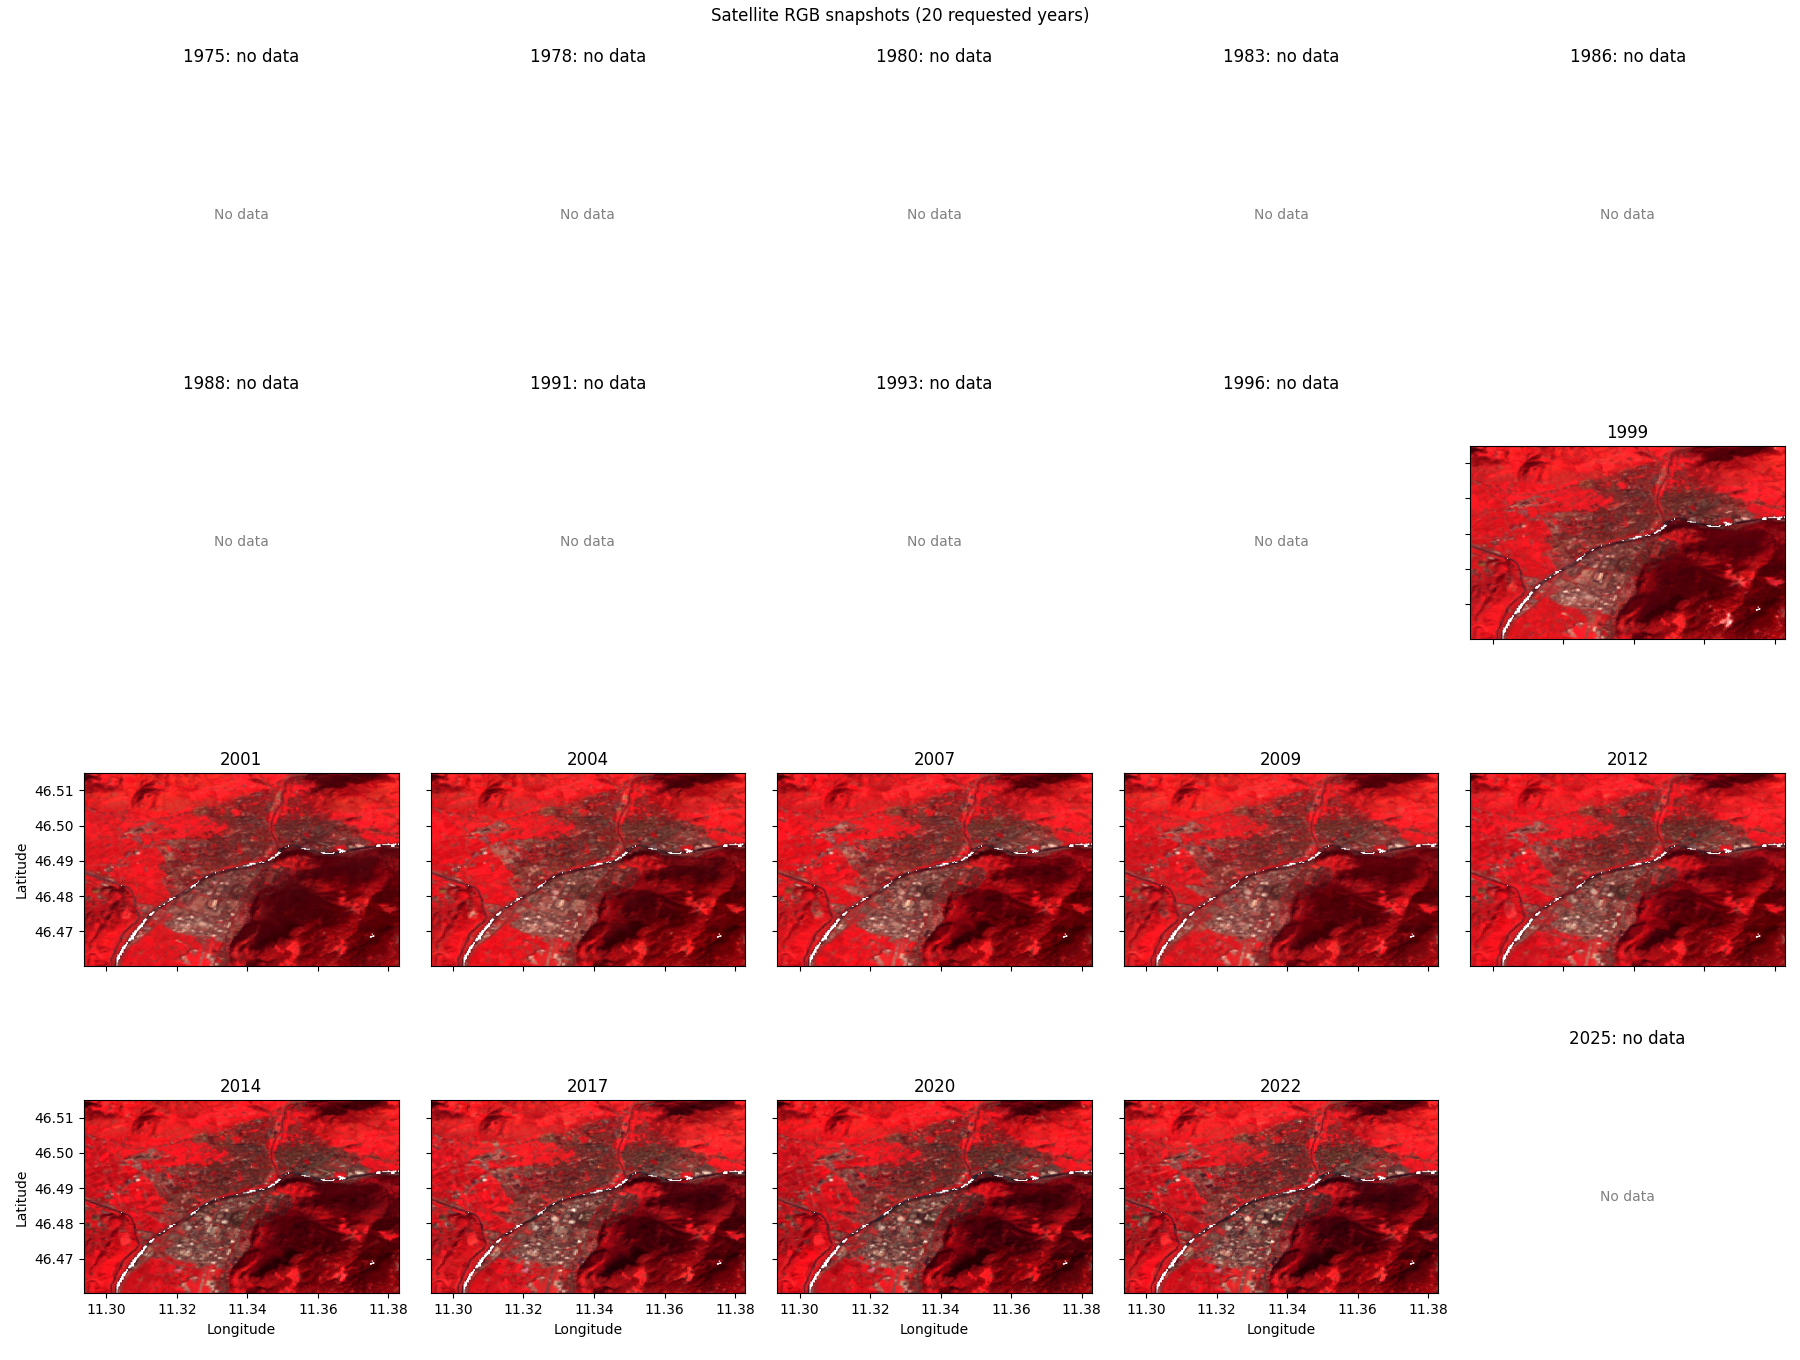

Requested -> used year mapping:
  1975: no data
  1978: no data
  1980: no data
  1983: no data
  1986: no data
  1988: no data
  1991: no data
  1993: no data
  1996: no data
  1999: 1999
  2001: 2001
  2004: 2004
  2007: 2007
  2009: 2009
  2012: 2012
  2014: 2014
  2017: 2017
  2020: 2020
  2022: 2022
  2025: no data


In [5]:
REQUEST_START_YEAR = 1975
REQUEST_END_YEAR = 2025
N_FIGURES = 20

available_years = yearly_rgb["year"].values.astype(int)
requested_years = np.round(np.linspace(REQUEST_START_YEAR, REQUEST_END_YEAR, N_FIGURES)).astype(int)

origin = "upper" if lats[0] > lats[-1] else "lower"
extent = [float(lons.min()), float(lons.max()), float(lats.min()), float(lats.max())]

ncols = 5
nrows = int(np.ceil(N_FIGURES / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 3.4 * nrows), sharex=True, sharey=True)
axes = np.array(axes).reshape(-1)

used_map = []
for ax, req_year in zip(axes, requested_years):
    if req_year < available_years.min() or req_year > available_years.max():
        ax.set_title(f"{req_year}: no data")
        ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes, color="gray")
        ax.set_axis_off()
        used_map.append((int(req_year), None))
        continue

    nearest_idx = np.argmin(np.abs(available_years - req_year))
    used_year = int(available_years[nearest_idx])

    red = yearly_rgb[RED_BAND].sel(year=used_year).values
    green = yearly_rgb[GREEN_BAND].sel(year=used_year).values
    blue = yearly_rgb[BLUE_BAND].sel(year=used_year).values

    rgb = np.stack([red, green, blue], axis=-1)
    p2 = np.nanpercentile(rgb, 2)
    p98 = np.nanpercentile(rgb, 98)
    if np.isfinite(p2) and np.isfinite(p98) and p98 > p2:
        rgb = (rgb - p2) / (p98 - p2)
    rgb = np.clip(rgb, 0, 1)

    ax.imshow(rgb, origin=origin, extent=extent)
    title = f"{req_year}" if used_year == req_year else f"{req_year} (used {used_year})"
    ax.set_title(title)
    used_map.append((int(req_year), used_year))

for ax in axes[len(requested_years):]:
    ax.set_axis_off()

for i, ax in enumerate(axes[:len(requested_years)]):
    if i % ncols == 0:
        ax.set_ylabel("Latitude")
    if i >= (nrows - 1) * ncols:
        ax.set_xlabel("Longitude")

fig.suptitle(f"Satellite RGB snapshots ({N_FIGURES} requested years)", y=0.995)
plt.tight_layout()
plt.show()

print("Requested -> used year mapping:")
for req, used in used_map:
    if used is None:
        print(f"  {req}: no data")
    else:
        print(f"  {req}: {used}")
